In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np
import gc

In [2]:
sell =pd.read_csv("sell_prices.csv")
sales = pd.read_csv('sales_train_evaluation.csv')
calendar = pd.read_csv("calendar.csv")

In [3]:
def downcast(df):
    cols = df.select_dtypes(include=['int64', 'int32']).columns
    df[cols] = df[cols].apply(pd.to_numeric, downcast='integer')
    
    cols = df.select_dtypes(include=['float64']).columns
    df[cols] = df[cols].apply(pd.to_numeric, downcast='float')
    
    obj_cols = df.select_dtypes(include=['object']).columns
    for col in obj_cols:
        df[col] = df[col].astype('category')
    return df

In [4]:
sell = downcast(sell)
sales = downcast(sales)
calendar = downcast(calendar)

In [5]:
df = pd.melt(sales, 
             id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
             var_name='d', 
             value_name='sales')

print(f"После Melt имеем строк: {len(df)}")
df = df.merge(calendar, on='d', how='left')
df = df.merge(sell, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

После Melt имеем строк: 59181090


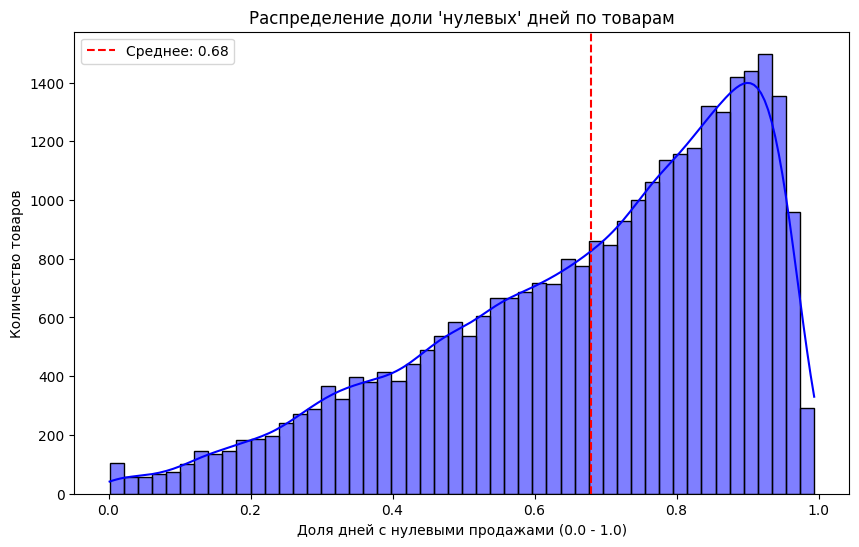

In [6]:
zero_counts = sales.iloc[:, 6:].apply(lambda x: (x == 0).mean(), axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(zero_counts, bins=50, kde=True, color='blue')
plt.title("Распределение доли 'нулевых' дней по товарам")
plt.xlabel("Доля дней с нулевыми продажами (0.0 - 1.0)")
plt.ylabel("Количество товаров")
plt.axvline(zero_counts.mean(), color='red', linestyle='--', label=f'Среднее: {zero_counts.mean():.2f}')
plt.legend()
plt.show()

In [7]:
df = df.sort_values(by=["id","date"])
df['day_int'] = df['d'].str[2:].astype(np.int16)
df["last_sale"] = np.where(df["sales"]>0,df["day_int"],np.nan)
df["last_sale"]= df.groupby("id",observed=True)["last_sale"].ffill()
df["day_since_last_sale"] = df["day_int"] -df["last_sale"]

In [8]:
nan_percent = df['sell_price'].isna().mean() * 100
print(f"Процент пропусков в столбце цены: {nan_percent:.2f}%")


df_ofnanprice = df[df["sell_price"].isna()]
df_ofnanprice["sales"]
leaked_sales = (df_ofnanprice["sales"] > 0).sum()
print(f"Количество строк с продажами при отсутствии цены: {leaked_sales}")

df["sell_price"] = df.groupby("id", observed=True)["sell_price"].bfill()

nan_percent = df['sell_price'].isna().mean() * 100
print(f"Процент пропусков в столбце цены после преобразования: {nan_percent:.2f}%")


Процент пропусков в столбце цены: 20.78%
Количество строк с продажами при отсутствии цены: 0
Процент пропусков в столбце цены после преобразования: 0.00%


In [9]:
df.drop(['d', 'wm_yr_wk',"day_int","last_sale"], axis=1, inplace=True)

In [10]:
def create_lags(df,days,rolling_window=None,dropna= False):
    df.sort_values(by=['id', 'date'], inplace=True)
    grouped = df.groupby('id',observed=True)['sales']
    max_lag = max(days)

    for lag in days:
        df[f"lags{lag}"] = grouped.shift(lag)

        if rolling_window is not None:
            df[f'rlag{rolling_window}_lag{lag}'] = (
                df.groupby('id',observed=True)[f'lags{lag}']
                .rolling(window=rolling_window)
                .mean()
                .reset_index(level=0, drop=True) 
                .astype("float32")
            )

    if dropna:
        if rolling_window:
            check_col = f'rlag{rolling_window}_lag{max_lag}'
        else:
            check_col = f'lag_{max_lag}'
        df.dropna(subset=check_col,inplace=True)

    return df

In [11]:
create_lags(df=df,days=[28,35],rolling_window=7,dropna=True)

,id,item_id,dept_id,cat_id,store_id,state_id,sales,date,weekday,wday,...,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,day_since_last_sale,lags28,rlag7_lag28,lags35,rlag7_lag35
1251702,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2011-03-11,Friday,7,...,NaN,0,1,1,2.00,1.0,1.0,0.857143,0.0,1.428571
1282192,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,2011-03-12,Saturday,1,...,NaN,0,1,1,2.00,0.0,3.0,1.000000,2.0,1.285714
1312682,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,5,2011-03-13,Sunday,2,...,NaN,0,1,0,2.00,0.0,0.0,1.000000,0.0,1.285714
1343172,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2011-03-14,Monday,3,...,NaN,0,0,1,2.00,1.0,2.0,1.285714,0.0,1.285714
1373662,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2011-03-15,Tuesday,4,...,NaN,0,1,1,2.00,2.0,1.0,1.428571,0.0,1.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59057692,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,0,2016-05-18,Wednesday,5,...,NaN,0,0,0,5.94,4.0,0.0,0.000000,0.0,0.000000
59088182,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,0,2016-05-19,Thursday,6,...,NaN,0,0,0,5.94,5.0,0.0,0.000000,0.0,0.000000
59118672,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,0,2016-05-20,Friday,7,...,NaN,0,0,0,5.94,6.0,0.0,0.000000,0.0,0.000000
59149162,HOUSEHOLD_2_516_WI_3_evaluation,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_3,WI,0,2016-05-21,Saturday,1,...,NaN,0,0,0,5.94,7.0,0.0,0.000000,0.0,0.000000


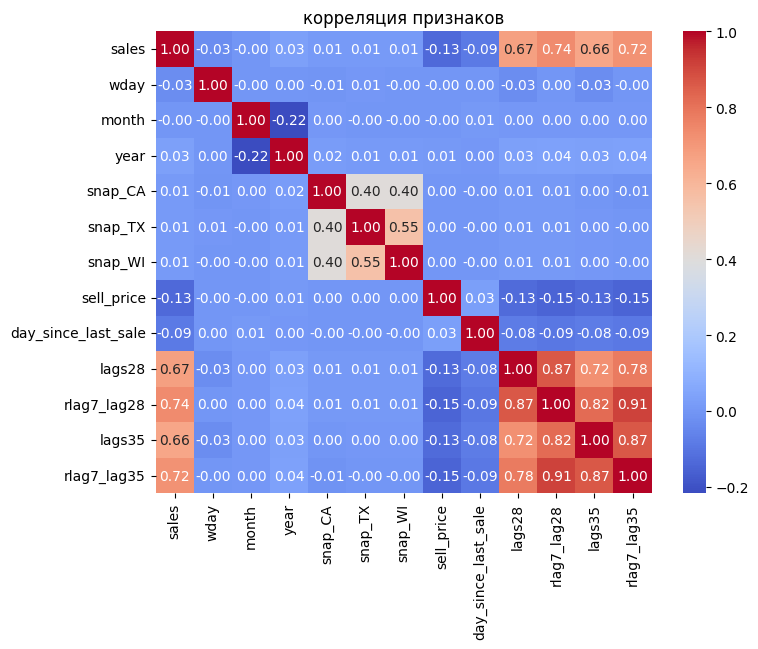

In [12]:
num_feuteres = df.select_dtypes(include="number").columns.to_list()

df_corr = df[num_feuteres].corr()

plt.figure(figsize=(8,6))
sns.heatmap(data=df_corr,cmap ="coolwarm",annot=True,fmt=".2f")
plt.title("корреляция признаков")
plt.show()


In [13]:
df.drop(columns=["dept_id","state_id","event_name_2","event_type_1","event_type_2"],inplace=True)

In [14]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values("date",inplace=True)
df.reset_index(drop=True, inplace=True)
df["event_name_1"] = df["event_name_1"].astype(str).replace('nan', 'None')
df["event_name_1"]=df["event_name_1"].fillna("None")
df["event_name_1"] = df["event_name_1"].astype('category')

df_small = df.tail(10000000).copy()

split = int(len(df_small)*0.8)
train_df = df_small[:split].copy()
test_df = df_small[split:].copy()
print(f'длина трейного датафрейма: {len(train_df)}, длина тестового датафрейма: {len(test_df)}')



event_means = train_df.groupby("event_name_1", observed=True)["sales"].mean()
train_df["event_target_enc"]=train_df["event_name_1"].map(event_means) 
test_df["event_target_enc"]=test_df["event_name_1"].map(event_means) 

item_means = train_df.groupby('item_id', observed=True)['sales'].mean()
train_df["item_target_enc"]=train_df["item_id"].map(item_means) 
test_df["item_target_enc"]=test_df["item_id"].map(item_means)



del df
gc.collect()


длина трейного датафрейма: 8000000, длина тестового датафрейма: 2000000


21745

In [15]:
X_train = train_df.drop(columns=['sales', 'date', 'id'],errors="ignore")
y_train = train_df["sales"]

X_test = test_df.drop(columns=['sales', 'date', 'id'],errors="ignore")
y_test = test_df["sales"]

del train_df, test_df
gc.collect()

0

In [16]:
# Кодируем категории вручную
cat_features = ['cat_id', 'store_id', 'wday', 'month']
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train[cat_features] = encoder.fit_transform(X_train[cat_features].astype(str))
X_test[cat_features] = encoder.transform(X_test[cat_features].astype(str))

train_data = lgb.Dataset(X_train, label=(y_train), categorical_feature=cat_features)
valid_data = lgb.Dataset(X_test, label=(y_test), categorical_feature=cat_features)

In [17]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'min_data_in_leaf': 100,      # Увеличиваем (было 100), чтобы еще сильнее размыть item_id
    'learning_rate': 0.03,  
    "lambda_l2" : 0.1,
    'num_leaves': 63,      
    'feature_pre_filter': False,
    'force_row_wise': True,
    'verbose': -1
}   

print("Начинаем обучение на сэмпле...")
model = lgb.train(
    params, 
    train_data, 
    num_boost_round=500, # Увеличим до 1000, раз мы закрутили регуляризацию
    valid_sets=[valid_data],
    callbacks=[lgb.log_evaluation(period=100),
               lgb.early_stopping(stopping_rounds=100)] 
)

Начинаем обучение на сэмпле...
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 1.89723
[200]	valid_0's rmse: 1.87477
[300]	valid_0's rmse: 1.86881
[400]	valid_0's rmse: 1.86561
[500]	valid_0's rmse: 1.86287
Did not meet early stopping. Best iteration is:
[498]	valid_0's rmse: 1.86286


In [18]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE на тестовой выборке: {rmse:.4f}")

RMSE на тестовой выборке: 1.8629


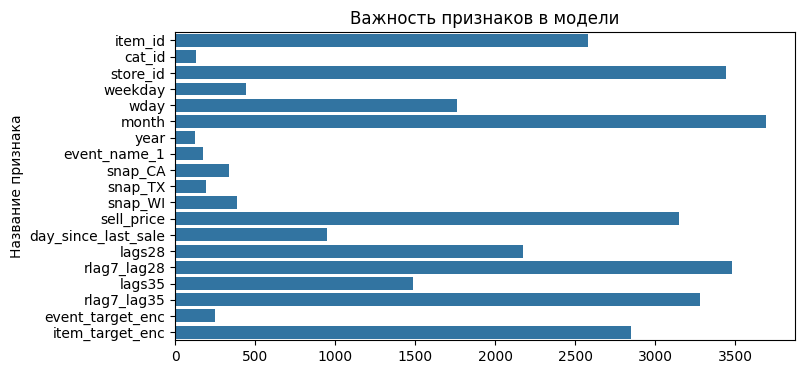

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=model.feature_importance(), 
    y=X_train.columns
)

plt.title('Важность признаков в модели')
plt.ylabel('Название признака')
plt.show()


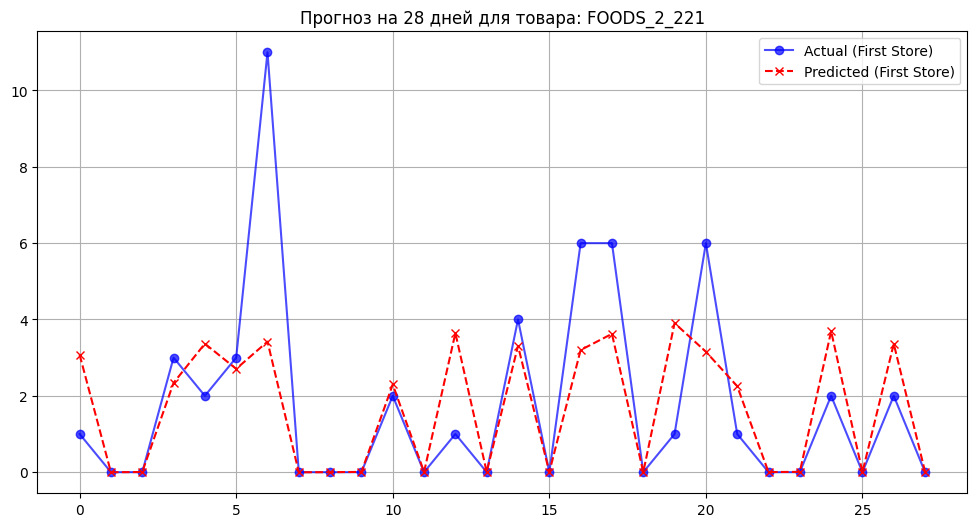

In [23]:
def plot_by_item_id(target_item_id, model, X_val, y_val):
    #  Фильтруем X_val по item_id
    # Используем .index, чтобы вытащить соответствующие значения из y_val
    item_mask = X_val['item_id'] == target_item_id
    
    if item_mask.sum() == 0:
        print(f"Item {target_item_id} не найден в валидационной выборке!")
        return

    preds = model.predict(X_val[item_mask])
    actual = y_val[item_mask].values
    
    
    plt.figure(figsize=(12, 6))
    plt.plot(actual[:28], label='Actual (First Store)', color='blue', alpha=0.7, marker='o')
    plt.plot(preds[:28], label='Predicted (First Store)', color='red', linestyle='--', marker='x')
    
    plt.title(f"Прогноз на 28 дней для товара: {target_item_id}")
    plt.legend()
    plt.grid(True)
    plt.show()

unique_items = X_test['item_id'].unique()
plot_by_item_id(unique_items[0], model, X_test, y_test)